# V2a-RSNs IC Quality Pipeline Example

This notebook demonstrates the hybrid bad-IC review pipeline for a V2a-RSNs dataset. It fits all four linear BSS methods by default, scores ICs with artifact/protect evidence, runs leave-one-IC-out validation, and writes auditable review reports for method comparison. Cleaned traces are only saved after manually filling `APPROVED_REJECT_COMPONENTS_BY_METHOD`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    p
    for p in candidates
    if (p / "pyproject.toml").exists() and (p / "src" / "bss_notebook.py").exists()
)
for path in (PROJECT_ROOT / "src", PROJECT_ROOT / "src" / "core"):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from behavior_decoding import make_behavior_targets
from bss_notebook import BSS_METHODS, run_bss_method, load_traces
from ic_quality import (
    reconstruct_with_rejected,
    run_ic_quality_pipeline,
    select_n_components_by_method,
)

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PROJECT_ROOT



PosixPath('/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising')

In [2]:
# Dataset and method selection
DATASET_KEY = "v2a-RSNs/220127_F4_run2_fluorescence"
METHODS_TO_RUN = ["fastica", "infomax", "jade"] # list(BSS_METHODS)
N_COMPONENTS = None  # set an int to force the same value across methods
N_COMPONENT_CANDIDATES = [20, 30, 40, 50, 60, 80]
AUTO_SELECT_N_COMPONENTS = True
DECOMPOSITION_TOL = 0.0001
DECOMPOSITION_MAX_ITER = 500
DECOMPOSITION_RANDOM_STATE = 0

SAVE_REVIEW_REPORT = True
SAVE_APPROVED_CLEANED = False
# Output layout root: outputs/linear/v2a-RSNs/ic_quality/v2a-RSNs/<method>/
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "linear" / "v2a-RSNs" / "ic_quality" / "v2a-RSNs"
ANALYSIS_KIND = "linear/v2a-RSNs/ic_quality"

# Fill only after reviewing the recommendations and validation evidence.
APPROVED_REJECT_COMPONENTS_BY_METHOD = {method: [] for method in BSS_METHODS}



In [3]:
dataset, traces = load_traces(DATASET_KEY, PROJECT_ROOT)
sample_rate_hz = dataset.sample_rate_hz or 1.0
behavior_targets = None

if dataset.tail_angle_path and dataset.tail_angle_path.exists():
    tail_angle = np.load(dataset.tail_angle_path, allow_pickle=False)
    behavior_targets = make_behavior_targets(tail_angle, n_frames=traces.shape[1])
print(f"dataset: {dataset.key}")
print(f"trace file: {dataset.trace_path.relative_to(PROJECT_ROOT)}")
print(f"traces: neurons={traces.shape[0]}, frames={traces.shape[1]}")
print(f"sample_rate_hz: {sample_rate_hz}")
print(f"behavior targets loaded: {behavior_targets is not None}")


dataset: v2a-RSNs/220127_F4_run2_fluorescence
trace file: data/v2a-RSNs/new_data_09112022/220127_F4_run2/220127_F4_F4_run2_after_dec_cells_fluorescence_signals.npy
traces: neurons=844, frames=3176
sample_rate_hz: 5.2962
behavior targets loaded: True


In [4]:
import time

selected_n_components_by_method = {method: N_COMPONENTS for method in METHODS_TO_RUN}
n_components_selection_scores = pd.DataFrame()

if N_COMPONENTS is None and AUTO_SELECT_N_COMPONENTS:
    print("Selecting n_components per method using IC-quality objective...")
    t_select = time.perf_counter()
    selected_n_components_by_method, n_components_selection_scores = select_n_components_by_method(
        traces=traces,
        methods=METHODS_TO_RUN,
        sample_rate_hz=sample_rate_hz,
        candidate_components=N_COMPONENT_CANDIDATES,
        behavior_targets=behavior_targets,
        tol=DECOMPOSITION_TOL,
        max_iter=DECOMPOSITION_MAX_ITER,
        random_state=DECOMPOSITION_RANDOM_STATE,
    )
    print(f"Selection finished in {time.perf_counter() - t_select:.1f}s")
    display(n_components_selection_scores)
else:
    print("Skipping auto-selection; using configured N_COMPONENTS per method.")



Selecting n_components per method using IC-quality objective...
Selection finished in 228.1s


,method,n_components,overall_score,artifact_gap,protect_gap,validation_gap,drop_fraction,keep_fraction,review_fraction,drop_count,keep_count,review_count
0,fastica,50,0.098412,0.294559,0.035294,0.000003,0.02,0.680000,0.300000,1,34,15
1,fastica,20,-0.048080,-0.435119,0.517857,0.003052,0.00,0.700000,0.300000,0,14,6
2,fastica,30,-0.056486,-0.411389,0.470000,0.002015,0.00,0.666667,0.333333,0,20,10
3,fastica,40,-0.062258,-0.388628,0.443056,0.001386,0.00,0.600000,0.400000,0,24,16
4,fastica,80,-0.064081,-0.426114,0.445761,0.000680,0.00,0.725000,0.275000,0,58,22
5,fastica,60,-0.064774,-0.430398,0.446212,0.000942,0.00,0.733333,0.266667,0,44,16
6,infomax,20,-0.055803,-0.427244,0.497436,0.004317,0.00,0.650000,0.350000,0,13,7
7,infomax,30,-0.056912,-0.447585,0.483092,0.002636,0.00,0.766667,0.233333,0,23,7
8,infomax,50,-0.057600,-0.474735,0.480000,0.001467,0.00,0.880000,0.120000,0,44,6
9,infomax,40,-0.058255,-0.465530,0.483586,0.001907,0.00,0.825000,0.175000,0,33,7


In [5]:
import time

results = {}
total_methods = len(METHODS_TO_RUN)
run_start = time.perf_counter()

for idx, method in enumerate(METHODS_TO_RUN, start=1):
    chosen = selected_n_components_by_method[method]
    t0 = time.perf_counter()
    print(f"[{idx}/{total_methods}] Starting decomposition for {method} (n_components={chosen})...")
    results[method] = run_bss_method(
        dataset_key=DATASET_KEY,
        method=method,
        n_components=chosen,
        reject_components=(),
        save_outputs=False,
        project_root=PROJECT_ROOT,
        tol=DECOMPOSITION_TOL,
        max_iter=DECOMPOSITION_MAX_ITER,
        random_state=DECOMPOSITION_RANDOM_STATE,
        analysis_kind=ANALYSIS_KIND,
    )
    dt = time.perf_counter() - t0
    print(f"[{idx}/{total_methods}] Finished {method} in {dt:.1f}s")

print(f"Completed decomposition for {total_methods} methods in {time.perf_counter() - run_start:.1f}s")
for method, result in results.items():
    chosen = selected_n_components_by_method[method]
    print(
        f"{method}: selected_n_components={chosen}, ic_comps={result.ic_comps.shape}, mixing={result.A.shape}, reconstruction={result.cleaned.shape}"
    )



[1/3] Starting decomposition for fastica (n_components=50)...
[1/3] Finished fastica in 1.0s
[2/3] Starting decomposition for infomax (n_components=20)...
[2/3] Finished infomax in 0.6s
[3/3] Starting decomposition for jade (n_components=50)...
[3/3] Finished jade in 9.0s
Completed decomposition for 3 methods in 10.7s
fastica: selected_n_components=50, ic_comps=(3176, 50), mixing=(844, 50), reconstruction=(3176, 844)
infomax: selected_n_components=20, ic_comps=(3176, 20), mixing=(844, 20), reconstruction=(3176, 844)
jade: selected_n_components=50, ic_comps=(3176, 50), mixing=(844, 50), reconstruction=(3176, 844)


In [6]:
quality_by_method = {}

for method, result in results.items():
    quality_by_method[method] = run_ic_quality_pipeline(
        ic_comps=result.ic_comps,
        mixing=result.A,
        mean=result.mean,
        sample_rate_hz=sample_rate_hz,
        reference_traces=traces.T,
        behavior_targets=behavior_targets,
        method=method,
        dataset=DATASET_KEY,
        output_dir=(OUTPUT_DIR / method) if SAVE_REVIEW_REPORT else None,
    )

recommendations = pd.concat(
    [quality.recommendations.assign(method=method) for method, quality in quality_by_method.items()],
    ignore_index=True,
)
validations = pd.concat(
    [quality.validation.assign(method=method) for method, quality in quality_by_method.items() if quality.validation is not None],
    ignore_index=True,
)

recommendations.head(12)


,method,component,ic_variance,ic_std,excess_kurtosis,abs_excess_kurtosis,robust_peak_density,max_abs_robust_z,lag1_autocorr,lag5_autocorr,...,reference_corr_delta,behavior_corr_full_angle,behavior_corr_removed_angle,behavior_corr_delta_angle,behavior_corr_full_vigor,behavior_corr_removed_vigor,behavior_corr_delta_vigor,behavior_corr_full_bout_state,behavior_corr_removed_bout_state,behavior_corr_delta_bout_state
0,fastica,6,1.0,1.0,39.967234,39.967234,0.015743,23.337868,0.791425,0.706746,...,-0.001204,-0.00006,0.002253,0.002194,-0.032785,-0.031326,-0.001460,-0.049406,-0.048291,-0.001115
1,fastica,41,1.0,1.0,15.484189,15.484189,0.051008,20.874623,0.929263,0.901986,...,-0.003399,-0.00006,-0.002151,0.002092,-0.032785,-0.032504,-0.000281,-0.049406,-0.049443,0.000037
2,fastica,45,1.0,1.0,71.916268,71.916268,0.016688,30.532830,0.896891,0.816384,...,-0.002541,-0.00006,0.003623,0.003563,-0.032785,-0.025168,-0.007618,-0.049406,-0.046177,-0.003229
3,fastica,38,1.0,1.0,62.156323,62.156323,0.016058,29.055016,0.932532,0.872875,...,-0.002196,-0.00006,0.006852,0.006792,-0.032785,-0.027745,-0.005041,-0.049406,-0.043810,-0.005596
4,fastica,48,1.0,1.0,87.240334,87.240334,0.013224,35.331221,0.943521,0.801533,...,-0.004062,-0.00006,0.000363,0.000303,-0.032785,-0.024506,-0.008280,-0.049406,-0.045068,-0.004338
5,fastica,47,1.0,1.0,27.205789,27.205789,0.015428,15.530370,0.859920,0.806560,...,-0.001094,-0.00006,0.002978,0.002919,-0.032785,-0.030576,-0.002210,-0.049406,-0.048144,-0.001262
6,fastica,13,1.0,1.0,18.825208,18.825208,0.020781,13.753114,0.882920,0.838670,...,-0.001369,-0.00006,-0.002928,0.002868,-0.032785,-0.026359,-0.006426,-0.049406,-0.042535,-0.006871
7,fastica,33,1.0,1.0,18.706193,18.706193,0.027078,14.023445,0.875390,0.837585,...,-0.003821,-0.00006,-0.012333,0.012274,-0.032785,-0.045112,0.012326,-0.049406,-0.054979,0.005574
8,fastica,4,1.0,1.0,31.977584,31.977584,0.019207,19.809962,0.868375,0.826006,...,-0.002964,-0.00006,0.005406,0.005346,-0.032785,-0.043548,0.010762,-0.049406,-0.055601,0.006195
9,fastica,14,1.0,1.0,17.313749,17.313749,0.020151,12.693358,0.845905,0.807066,...,-0.002133,-0.00006,-0.000746,0.000686,-0.032785,-0.029510,-0.003276,-0.049406,-0.042951,-0.006455


In [7]:
review_columns = [
    "component",
    "recommendation",
    "artifact_score",
    "protect_score",
    "artifact_flags",
    "protect_flags",
    "high_freq_power_ratio",
    "robust_peak_density",
    "abs_excess_kurtosis",
    "max_abs_behavior_corr",
    "reference_corr_delta",
    "mean_abs_delta",
]
available_columns = [column for column in review_columns if column in recommendations.columns]
summary = (
    recommendations
    .groupby(["method", "recommendation"])
    .size()
    .unstack(fill_value=0)
)
score_summary = recommendations.groupby("method")[["artifact_score", "protect_score"]].mean()
display(summary.join(score_summary))
recommendations[available_columns].head(30)


,drop,keep,review,artifact_score,protect_score
method,,,,,
fastica,1,36,13,0.510,0.510
infomax,0,13,7,0.525,0.525
jade,1,36,13,0.510,0.510


,component,recommendation,artifact_score,protect_score,artifact_flags,protect_flags,high_freq_power_ratio,robust_peak_density,abs_excess_kurtosis,max_abs_behavior_corr,reference_corr_delta,mean_abs_delta
0,6,drop,0.710000,0.413333,heavy_tailed;nonstationary;concentrated_loading,slow_calcium_band;autocorrelated,0.0,0.015743,39.967234,0.013452,-0.001204,0.114518
1,41,review,0.855000,0.746667,bursty;heavy_tailed;nonstationary;concentrated...,slow_calcium_band;autocorrelated,0.0,0.051008,15.484189,0.045052,-0.003399,0.152481
2,45,review,0.848333,0.753333,heavy_tailed;nonstationary;concentrated_loading,slow_calcium_band;autocorrelated,0.0,0.016688,71.916268,0.039178,-0.002541,0.122656
3,38,review,0.838333,0.853333,heavy_tailed;nonstationary;concentrated_loading,slow_calcium_band;autocorrelated,0.0,0.016058,62.156323,0.051568,-0.002196,0.129161
4,48,review,0.835000,0.780000,heavy_tailed;nonstationary;concentrated_loading,slow_calcium_band;autocorrelated,0.0,0.013224,87.240334,0.036361,-0.004062,0.143607
5,47,review,0.748333,0.693333,heavy_tailed;nonstationary;concentrated_loading,slow_calcium_band;autocorrelated,0.0,0.015428,27.205789,0.041546,-0.001094,0.117818
6,13,review,0.738333,0.806667,bursty;heavy_tailed;nonstationary;concentrated...,slow_calcium_band;autocorrelated,0.0,0.020781,18.825208,0.055503,-0.001369,0.150272
7,33,review,0.738333,0.720000,bursty;heavy_tailed;nonstationary;concentrated...,slow_calcium_band;autocorrelated,0.0,0.027078,18.706193,0.041194,-0.003821,0.226701
8,4,review,0.721667,0.653333,heavy_tailed;nonstationary;concentrated_loading,slow_calcium_band;autocorrelated,0.0,0.019207,31.977584,0.031674,-0.002964,0.207555
9,14,review,0.671667,0.573333,bursty;heavy_tailed;nonstationary;concentrated...,slow_calcium_band;autocorrelated,0.0,0.020151,17.313749,0.030193,-0.002133,0.195335


In [8]:
if not validations.empty:
    display(
        validations.sort_values(["method", "mean_abs_delta"], ascending=[True, False]).groupby("method").head(8)
    )
else:
    print("No validation table was created because reference_traces was not supplied.")


,component,mean_abs_delta,rms_delta,reference_corr_full,reference_corr_removed,variance_ratio_median_removed,reference_corr_delta,behavior_corr_full_angle,behavior_corr_removed_angle,behavior_corr_delta_angle,behavior_corr_full_vigor,behavior_corr_removed_vigor,behavior_corr_delta_vigor,behavior_corr_full_bout_state,behavior_corr_removed_bout_state,behavior_corr_delta_bout_state,method
2,2,0.242914,0.513015,0.982633,0.980623,0.621716,-0.002010,-0.000060,-0.000225,0.000166,-0.032785,-0.032859,0.000074,-0.049406,-0.049366,-0.000040,fastica
33,33,0.226701,0.707059,0.982633,0.978812,0.599010,-0.003821,-0.000060,-0.012333,0.012274,-0.032785,-0.045112,0.012326,-0.049406,-0.054979,0.005574,fastica
32,32,0.223856,0.642545,0.982633,0.979478,0.601111,-0.003154,-0.000060,-0.022136,0.022076,-0.032785,-0.059112,0.026327,-0.049406,-0.073094,0.023688,fastica
28,28,0.218212,0.580891,0.982633,0.980056,0.596015,-0.002577,-0.000060,-0.001510,0.001450,-0.032785,-0.032667,-0.000118,-0.049406,-0.047323,-0.002083,fastica
10,10,0.212761,0.610308,0.982633,0.979788,0.606293,-0.002845,-0.000060,0.000185,0.000126,-0.032785,-0.043799,0.011014,-0.049406,-0.058665,0.009259,fastica
36,36,0.211830,0.494667,0.982633,0.980765,0.620976,-0.001868,-0.000060,-0.006647,0.006587,-0.032785,-0.037251,0.004466,-0.049406,-0.051732,0.002327,fastica
4,4,0.207555,0.622904,0.982633,0.979669,0.591132,-0.002964,-0.000060,0.005406,0.005346,-0.032785,-0.043548,0.010762,-0.049406,-0.055601,0.006195,fastica
11,11,0.206044,0.560543,0.982633,0.980233,0.614928,-0.002400,-0.000060,0.002794,0.002735,-0.032785,-0.029536,-0.003249,-0.049406,-0.047233,-0.002173,fastica
50,0,0.891055,1.744835,0.976496,0.952841,0.369209,-0.023655,-0.000586,-0.033024,0.032438,-0.035821,-0.048757,0.012936,-0.052549,-0.061429,0.008881,infomax
51,1,0.750228,1.355496,0.976496,0.962290,0.377344,-0.014206,-0.000586,0.041829,0.041243,-0.035821,-0.156653,0.120831,-0.052549,-0.136362,0.083813,infomax


Inspecting candidate ICs for fastica


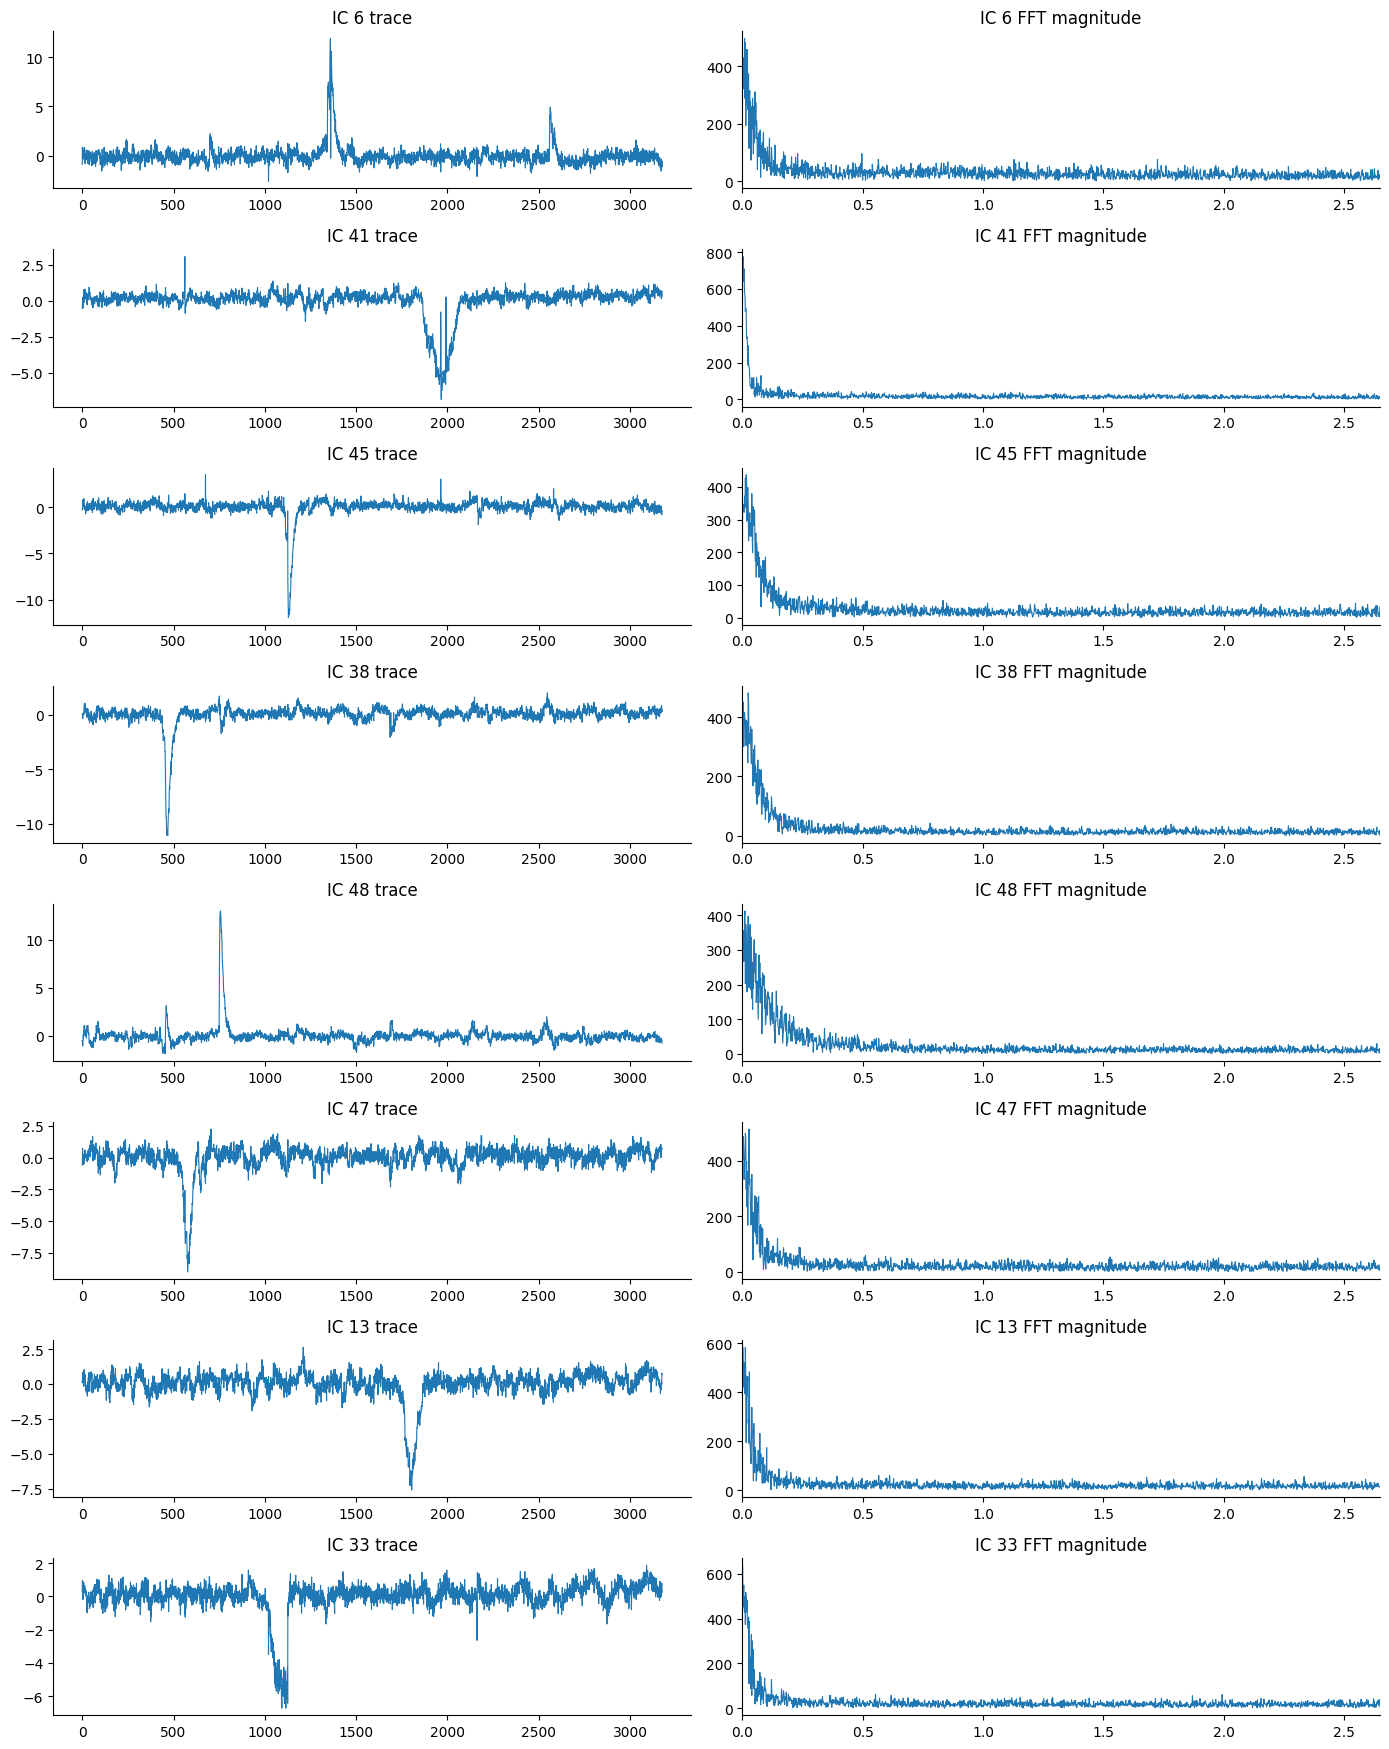

In [9]:
INSPECT_METHOD = METHODS_TO_RUN[0]
quality = quality_by_method[INSPECT_METHOD]
result = results[INSPECT_METHOD]

candidate_components = (
    quality.recommendations
    .query("recommendation in ['drop', 'review']")
    .head(8)["component"]
    .astype(int)
    .tolist()
)

if not candidate_components:
    candidate_components = quality.recommendations.head(8)["component"].astype(int).tolist()

print(f"Inspecting candidate ICs for {INSPECT_METHOD}")
fig, axes = plt.subplots(len(candidate_components), 2, figsize=(14, 2.2 * len(candidate_components)))
if len(candidate_components) == 1:
    axes = np.array([axes])

for row_idx, component in enumerate(candidate_components):
    trace = result.ic_comps[:, component]
    axes[row_idx, 0].plot(trace, lw=0.8)
    axes[row_idx, 0].set_title(f"IC {component} trace")
    freqs = np.fft.rfftfreq(trace.size, d=1.0 / sample_rate_hz)
    power = np.abs(np.fft.rfft(trace))
    axes[row_idx, 1].plot(freqs, power, lw=0.8)
    axes[row_idx, 1].set_xlim(0, sample_rate_hz / 2)
    axes[row_idx, 1].set_title(f"IC {component} FFT magnitude")

fig.tight_layout()


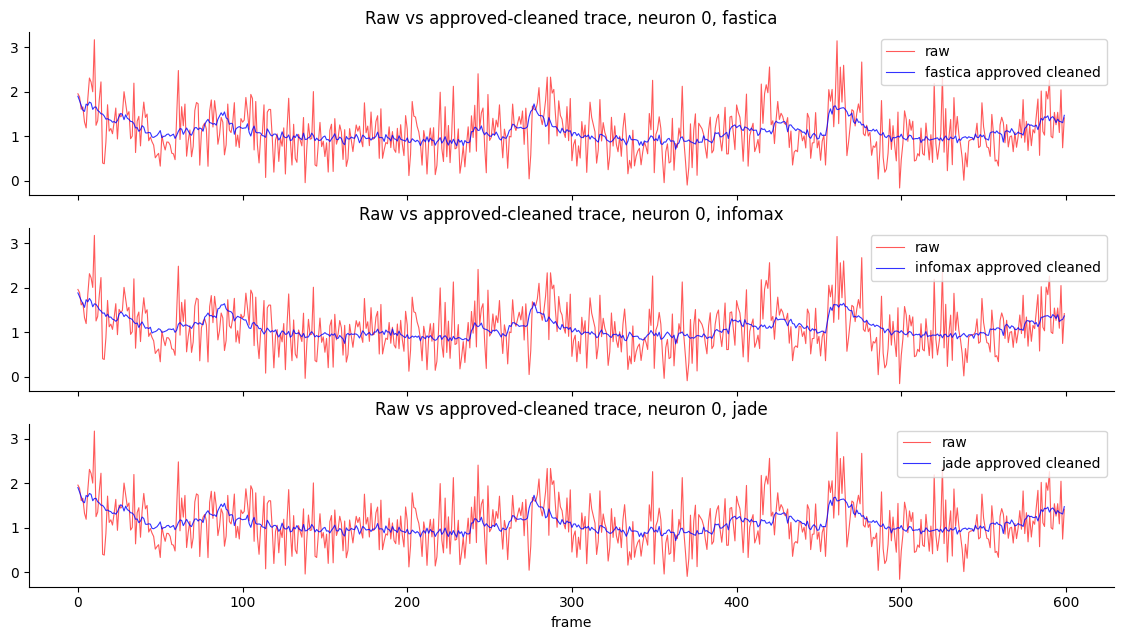

In [10]:
approved_cleaned_by_method = {}
for method, result in results.items():
    approved_cleaned_by_method[method] = reconstruct_with_rejected(
        result.ic_comps,
        result.A,
        result.mean,
        reject_components=APPROVED_REJECT_COMPONENTS_BY_METHOD.get(method, []),
    )

neuron_idx = 0
time_slice = slice(0, min(600, traces.shape[1]))
fig, axes = plt.subplots(len(results), 1, figsize=(14, 2.4 * len(results)), sharex=True)
if len(results) == 1:
    axes = [axes]
for ax, (method, cleaned) in zip(axes, approved_cleaned_by_method.items()):
    ax.plot(traces[neuron_idx, time_slice], color="red", alpha=0.65, lw=0.8, label="raw")
    ax.plot(cleaned[time_slice, neuron_idx], color="blue", alpha=0.8, lw=0.8, label=f"{method} approved cleaned")
    ax.set_title(f"Raw vs approved-cleaned trace, neuron {neuron_idx}, {method}")
    ax.legend(loc="upper right")
axes[-1].set_xlabel("frame");


In [11]:
if SAVE_APPROVED_CLEANED:
    for method, cleaned in approved_cleaned_by_method.items():
        method_dir = OUTPUT_DIR / method
        method_dir.mkdir(parents=True, exist_ok=True)
        cleaned_path = method_dir / f"approved_cleaned_{method}_{dataset.data_name}.npy"
        reject_path = method_dir / f"approved_reject_components_{method}_{dataset.data_name}.txt"
        approved_rejects = APPROVED_REJECT_COMPONENTS_BY_METHOD.get(method, [])
        np.save(cleaned_path, cleaned.T)
        reject_path.write_text(",".join(str(component) for component in approved_rejects), encoding="utf-8")
        print(f"{method} cleaned traces: {cleaned_path.relative_to(PROJECT_ROOT)}")
        print(f"{method} rejected IC list: {reject_path.relative_to(PROJECT_ROOT)}")
else:
    print("SAVE_APPROVED_CLEANED is False; approved reconstruction was not saved.")

for method, quality in quality_by_method.items():
    if quality.saved_paths:
        print(f"{method} review outputs:")
        for label, path in quality.saved_paths.items():
            print(f"  {label}: {path.relative_to(PROJECT_ROOT)}")


SAVE_APPROVED_CLEANED is False; approved reconstruction was not saved.
fastica review outputs:
  features: outputs/ic_quality/v2a-RSNs/fastica/ic_quality_table.csv
  recommendations: outputs/ic_quality/v2a-RSNs/fastica/ic_rejection_recommendations.csv
  metadata: outputs/ic_quality/v2a-RSNs/fastica/ic_quality_metadata.json
  html_report: outputs/ic_quality/v2a-RSNs/fastica/ic_review_report.html
  validation: outputs/ic_quality/v2a-RSNs/fastica/ic_leave_one_out_validation.csv
infomax review outputs:
  features: outputs/ic_quality/v2a-RSNs/infomax/ic_quality_table.csv
  recommendations: outputs/ic_quality/v2a-RSNs/infomax/ic_rejection_recommendations.csv
  metadata: outputs/ic_quality/v2a-RSNs/infomax/ic_quality_metadata.json
  html_report: outputs/ic_quality/v2a-RSNs/infomax/ic_review_report.html
  validation: outputs/ic_quality/v2a-RSNs/infomax/ic_leave_one_out_validation.csv
jade review outputs:
  features: outputs/ic_quality/v2a-RSNs/jade/ic_quality_table.csv
  recommendations: outpu